  **Project Team:** Ruth Tolulope Faseun, Tyler Brantingham, Liam Kapples  
  **Due Date:** 4/12/2026                
  **Class:** DX 799 Spring 2026  

  **Notes:** 
  - Notebook was run in a Google Colab environment.  
  - PyTorch was used due to a version conflict with Tensorflow

# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.** 
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [1]:
# import os, tensorflow as tf                                                                                                                                                                                                           
# print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH","NOT SET")[:80])                                                                                                                                                           
# print("GPU:", tf.config.list_physical_devices("GPU"))   

In [2]:

# --- Standard Libraries
import os
import time
import math
import random
import datetime
from datetime import datetime
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


I0000 00:00:1775953856.876602   33067 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# ── WSL GPU Configuration ────────────────────────────────────────────────────
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU(s) enabled: {[g.name for g in gpus]}")
else:
    print("WARNING: No GPU found — running on CPU")


GPU(s) enabled: ['/physical_device:GPU:0']


In [4]:
# additional imports for framework compatibility
from datetime import datetime
from pathlib import Path
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Embedding, GlobalAveragePooling1D, Dense, 
    Dropout, BatchNormalization, LSTM, Bidirectional
)
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [5]:
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

In [6]:
import os, zipfile, urllib.request
from pathlib import Path
import numpy as np
from tensorflow.keras.datasets import imdb

# -----------------------------
# GloVe Setup (auto-download)
# -----------------------------
GLOVE_DIR = Path(os.environ.get("GLOVE_DIR", "data/glove")).expanduser()
GLOVE_DIR.mkdir(parents=True, exist_ok=True)

GLOVE_6B_URL = "https://nlp.stanford.edu/data/glove.6B.zip"

def ensure_glove_6b(download_dir: Path) -> Path:
    zip_path = download_dir / "glove.6B.zip"
    extracted_dir = download_dir / "glove.6B"

    if extracted_dir.exists() and any(extracted_dir.glob("glove.6B.*d.txt")):
        return extracted_dir

    if not zip_path.exists():
        print(f"Downloading GloVe 6B to: {zip_path}")
        urllib.request.urlretrieve(GLOVE_6B_URL, zip_path)

    print(f"Extracting: {zip_path} -> {download_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(download_dir)

    if extracted_dir.exists():
        return extracted_dir
    if any(download_dir.glob("glove.6B.*d.txt")):
        return download_dir

    raise FileNotFoundError("GloVe files not found after extraction.")

def load_glove_vectors(glove_folder: Path, embedding_dimension: int) -> dict:
    glove_path = glove_folder / f"glove.6B.{embedding_dimension}d.txt"
    if not glove_path.exists():
        raise FileNotFoundError(
            f"Missing {glove_path}. Re-run the setup cell or check your GLOVE_DIR."
        )

    embeddings_index = {}
    with glove_path.open(encoding="utf8") as f:
        for line in f:
            word, *vec = line.split()
            embeddings_index[word] = np.asarray(vec, dtype="float32")
    return embeddings_index

def build_embedding_matrix(training_vocabulary_size: int, embedding_dimension: int) -> np.ndarray:
    glove_folder = ensure_glove_6b(GLOVE_DIR)
    embeddings_index = load_glove_vectors(glove_folder, embedding_dimension)

    word_index = imdb.get_word_index()
    embedding_matrix = np.zeros((training_vocabulary_size, embedding_dimension), dtype="float32")

    for word, raw_idx in word_index.items():
        idx = raw_idx + 3
        if idx >= training_vocabulary_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

    return embedding_matrix

GLOVE_FOLDER = ensure_glove_6b(GLOVE_DIR)
print(f"GloVe folder ready: {GLOVE_FOLDER}")

Extracting: data/glove/glove.6B.zip -> data/glove
GloVe folder ready: data/glove


In [7]:
def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

In [8]:
def train_and_test(model, 
                   title         = "Learning Curves",
                   epochs        = 200,                   # Just needs to be bigger than early stopping point
                   optimizer     = "Adam",
                   lr_schedule   = 1e-3,                  # Adam defaults 
                   clipnorm      = None,                 
                   batch_size    = 128,  
                   loss          = "binary_crossentropy",
                   metrics       = ["accuracy"],
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule,clipnorm=clipnorm) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer = opt, 
                  loss      = loss, 
                  metrics   = metrics
                 )

  

    if use_early_stopping:
        early_stop = EarlyStopping(
            monitor              = 'val_loss',
            patience             = patience,
            min_delta            = min_delta,
            restore_best_weights = True,               # this will mean that the model which produced the smallest validation loss will be returned
            verbose              = verbose
        ) 
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    # If X_val defined, then  use it, else assume val is split from train

    if 'X_val' in globals():
        history = model.fit(X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(X_val, y_val),      
                            callbacks=cbs,
                            verbose=verbose
                           )
    else:
        history = model.fit(X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_split=0.2,      
                            callbacks=cbs,
                            verbose=verbose
                           )        

    # Plot training history
    plot_learning_curves(history, title=title)

    # Find epoch with minimum validation loss
    min_val_epoch = np.argmin(history.history['val_loss'])
    # Retrieve the values at that epoch
    min_val_loss = history.history['val_loss'][min_val_epoch]    
    # Get corresponding validation accuracy at that epoch
    val_acc_at_min_loss = history.history['val_accuracy'][min_val_epoch]

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    # Print out results

    print(f"\nFinal Training Loss:            {history.history['loss'][-1]:.4f}")
    print(f"Final Training Accuracy:        {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Loss:          {history.history['val_loss'][-1]:.4f}")
    print(f"Final Validation Accuracy:      {history.history['val_accuracy'][-1]:.4f}")
    print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
    print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Accuracy Gap: {abs(val_acc_at_min_loss - test_accuracy):.6f}")

    # Store accuracy in results
    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

    # Store all information about run in parameter_settings
    
    global parameter_settings
    entry = {
        "title": title,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "epochs": int(epochs),
        "optimizer": optimizer,
        "lr_schedule": lr_schedule,
        "clipnorm": clipnorm,
        "loss": loss,
        "batch_size": batch_size,
        "use_early_stopping": use_early_stopping,
        "patience": patience,
        "min_delta": min_delta,
        "callbacks": _summarize_callbacks(callbacks),
        "Final Training Loss" : history.history['loss'][-1],
        "Final Training Accuracy" : history.history['accuracy'][-1],
        "Final Val Loss" : history.history['val_loss'][-1],
        "Final Val Accuracy" : history.history['val_accuracy'][-1],
        "Min Val Loss" : min_val_loss,
        "Min Val Loss Epoch" : min_val_epoch,
        "Val Acc @ Min Loss" : val_acc_at_min_loss,
        "Test Loss" : test_loss,
        "Test Acc" : test_accuracy,
        "Val-Test Accuracy Gap:" : abs(val_acc_at_min_loss - test_accuracy)
    }
    parameter_settings.setdefault(title, []).append(entry)  

    if return_history:
        return history

def _summarize_callbacks(cbs):
    if cbs is None:
        return None
    out = []
    for cb in cbs:
        name = getattr(cb, "__class__", type(cb)).__name__
        info = {"class": name}
        # grab a few common attributes if present
        for attr in ("monitor", "mode", "patience", "min_delta",
                     "factor", "min_lr", "verbose", "cooldown"):
            if hasattr(cb, attr):
                info[attr] = getattr(cb, attr)
        out.append(info)
    return out

results = {}
parameter_settings = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

In [9]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-5,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-8,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

#  put in the callbacks list:

#    train_and_test(model, title="Learning Curves",callbacks=[reduce_lr])

In [10]:
def build_embedding_matrix_huffpost(vocab_size, embedding_dim):
    vocab = vectorize_layer.get_vocabulary()
    word_index = {word: idx for idx, word in enumerate(vocab)}
    embeddings_index = load_glove_vectors(GLOVE_FOLDER, embedding_dim)
    embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype='float32')
    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec
    return embedding_matrix

In [11]:
import urllib.request

# download directly
urllib.request.urlretrieve(
    "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json",
    "huffpost.json"
)

# load from local file
huff_all = load_dataset("json", data_files="huffpost.json", split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


In [12]:
ex = huff_all[0]
print(ex)

{'category': 'CRIME', 'headline': 'There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV', 'authors': 'Melissa Jeltsen', 'link': 'https://www.huffingtonpost.com/entry/texas-amanda-painter-mass-shooting_us_5b081ab4e4b0802d69caad89', 'short_description': 'She left her husband. He killed their children. Just another day in America.', 'date': datetime.datetime(2018, 5, 26, 0, 0)}


In [13]:
ex.keys()

dict_keys(['category', 'headline', 'authors', 'link', 'short_description', 'date'])

In [14]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


In [15]:
df = pd.DataFrame({
    "category":          huff_all["category"],
    "headline":          huff_all["headline"],
    "short_description": huff_all["short_description"],
    "authors":           huff_all["authors"],
    "date":              huff_all["date"]
})

In [16]:
df.shape

(200853, 5)

In [17]:
df.head()

,category,headline,short_description,authors,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,She left her husband. He killed their children...,Melissa Jeltsen,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Of course it has a song.,Andy McDonald,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,The actor and his longtime girlfriend Anna Ebe...,Ron Dicker,2018-05-26
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,The actor gives Dems an ass-kicking for not fi...,Ron Dicker,2018-05-26
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,"The ""Dietland"" actress said using the bags is ...",Ron Dicker,2018-05-26


In [18]:
# strip whitespace
df['headline'] = df['headline'].str.strip()
df['short_description'] = df['short_description'].str.strip()

# drop
df = df[df['headline'] != ""]

# replace empty samples with ""
df['short_description'] = df['short_description'].replace('', np.nan).fillna('')

empty_desc_count = (df['short_description'] == "").sum()
print(f"Rows after cleaning: {df.shape[0]}")
print(f"Rows with empty desc:    {empty_desc_count}")
df.head()

Rows after cleaning: 200847
Rows with empty desc:    19707


,category,headline,short_description,authors,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,She left her husband. He killed their children...,Melissa Jeltsen,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Of course it has a song.,Andy McDonald,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,The actor and his longtime girlfriend Anna Ebe...,Ron Dicker,2018-05-26
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,The actor gives Dems an ass-kicking for not fi...,Ron Dicker,2018-05-26
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,"The ""Dietland"" actress said using the bags is ...",Ron Dicker,2018-05-26


In [19]:
# concatenate & lowercase
df['text'] = (df['headline'] + " [SEP] " + df['short_description']).str.lower()

# check for dupes
num_dupes = df['text'].duplicated().sum()
print(f"Duplicate rows found: {num_dupes}")

# drop dupes
df = df.drop_duplicates(subset='text').reset_index(drop=True)

print(f"Rows after deduplication: {df.shape[0]}")
df[['category', 'text']].head()

Duplicate rows found: 491
Rows after deduplication: 200356


,category,text
0,CRIME,there were 2 mass shootings in texas last week...
1,ENTERTAINMENT,will smith joins diplo and nicky jam for the 2...
2,ENTERTAINMENT,hugh grant marries for the first time at age 5...
3,ENTERTAINMENT,jim carrey blasts 'castrato' adam schiff and d...
4,ENTERTAINMENT,julianna margulies uses donald trump poop bags...


In [20]:

# get unique categories and sort
unique_categories = sorted(df['category'].unique())

# encode category column
df['category'] = pd.Categorical(df['category'], categories=unique_categories)

# assign integer codes new column
df['label'] = df['category'].cat.codes

print(f"Number of unique classes: {df['label'].nunique()}")
print("\n Sample label mapping (first 5):")
for i, cat in enumerate(unique_categories[:5]):
    print(f"  {i:2d} → {cat}")


Number of unique classes: 41

 Sample label mapping (first 5):
   0 → ARTS
   1 → ARTS & CULTURE
   2 → BLACK VOICES
   3 → BUSINESS
   4 → COLLEGE


In [21]:
from tensorflow.keras.layers import TextVectorization

vectorize_layer = TextVectorization(
    max_tokens=20000,
    output_mode='int',
    output_sequence_length=128
)
vectorize_layer.adapt(df['text'].values)   

vocab = vectorize_layer.get_vocabulary()
print(f"Vocabulary size: {len(vocab)}")

I0000 00:00:1775953881.278652   33067 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:06:00.0, compute capability: 8.6


Vocabulary size: 20000


In [22]:
from sklearn.model_selection import train_test_split

texts  = np.array(df["text"].values)
labels = np.array(df["label"].values)

# 1st split 80% train/20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# 2nd split cut 20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Val size:   {len(X_val)}")
print(f"Test size:  {len(X_test)}")


Train size: 160284
Val size:   20036
Test size:  20036


In [23]:
# save integer labels bf one-hot encoding
y_train_int = y_train.copy()
y_val_int   = y_val.copy()
y_test_int  = y_test.copy()

In [24]:
X_train_vec = vectorize_layer(X_train)
X_val_vec   = vectorize_layer(X_val)
X_test_vec  = vectorize_layer(X_test)

In [25]:
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=41)
y_val_cat   = tf.keras.utils.to_categorical(y_val,   num_classes=41)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  num_classes=41)

In [26]:
# Align variable names with train_and_test() framework
X_train, X_val, X_test = X_train_vec, X_val_vec, X_test_vec
y_train, y_val, y_test = y_train_cat, y_val_cat, y_test_cat

In [27]:
from sklearn.utils.class_weight import compute_class_weight

# Use original integer labels not the one-hot encoded y_train
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weight_dict = dict(enumerate(class_weights))

print(f"Number of classes with weights: {len(class_weight_dict)}")
print(f"\nSample weights:")
for i in [0, 5, 10, 20, 40]:
    print(f"  Class {i:2d} ({unique_categories[i]:25s}): {class_weight_dict[i]:.4f}")

Number of classes with weights: 41

Sample weights:
  Class  0 (ARTS                     ): 3.2389
  Class  5 (COMEDY                   ): 0.9466
  Class 10 (ENTERTAINMENT            ): 0.3044
  Class 20 (MEDIA                    ): 1.7375
  Class 40 (WORLDPOST                ): 1.8959


In [28]:
# representative examples after full preprocessing
for i in [0, 1, 2]:
    print(f"Example {i+1}")
    print(f"  Text:    {X_train_vec[i][:10].numpy()}...")
    print(f"  Label:   {y_train_int[i]} ({unique_categories[y_train_int[i]]})")
    print()

Example 1
  Text:    [ 329  277 1231   11   17 4755   20  448    7   36]...
  Label:   30 (STYLE & BEAUTY)

Example 2
  Text:    [  68   52  677   52 1612   83    1   65    3  211]...
  Label:   24 (POLITICS)

Example 3
  Text:    [ 5188    74    14   661     3    22    13 10402     5   150]...
  Label:   37 (WELLNESS)



### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**
> <font color="teal"> Loaded the huffpost dataset from HuggingFace using load_dataset. For cleaning, we dropped the link column and kept 5 columns, stripped whitespace, dropped 6 empty headlines as they were not useful for classification, filled 19,707 empty descriptions with "", transformed text to lowercase, concatenated headline and description, and removed 491 duplicate text entries. After cleaning we were left with 200,356 rows. </font>


2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**
> <font color="teal"> We concatenated to ensure the model can consume a single input. We used lowercase for GloVe compatibility to make sure that "Growth" and "growth" would map to the same token and prevent waste while promoting vocabulary efficiency. The text vectorization was done per the instructions with 20,000 vocab, 128 max length was chosen based on the 95th percentile of combined text length from Milestone 1 EDA, and padding and truncation. </font>


3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**

> <font color="teal"> We we used class stratification on the labels to ensure that each split maintains the same class distribution as the original daatset. This was critical given our 32x imbalance ratio and gives a chance for minority classes to appear proportionally in all three subsets. The train test split was 80/10/10 per the instructions using a two stage split, with random seed 42. The final subset sizes were 160,284 / 20,036 / 20,036. </font>



4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**
> <font color="teal"> There were 41 class labels. The largest class was politics with 32,739 articles and the smallest being education with 1,004 articles, giving an imbalance ratio of 32x. There was major class imbalance so we added balanced weights to the training data with compute_class_weight('balanced') to prevent leakage from validation and tests sets. </font>


## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.


Baseline



I0000 00:00:1775953886.427999   33305 service.cc:153] XLA service 0x76c774086d00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775953886.428025   33305 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.3.0)
I0000 00:00:1775953886.444325   33305 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775953886.513563   33305 cuda_dnn.cc:461] Loaded cuDNN version 90300
I0000 00:00:1775953886.520057   33305 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1527__.19
I0000 00:00:1775953886.532438   33305 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I000

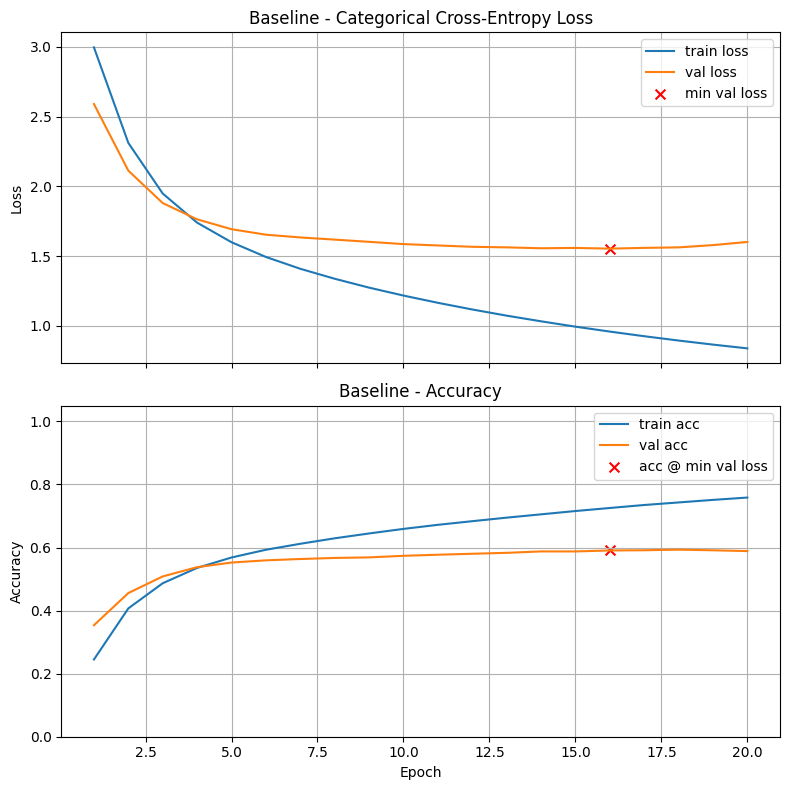

I0000 00:00:1775953961.452281   33305 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775953961.830325   35353 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 84 bytes spill stores, 84 bytes spill loads




Execution Time: 00:01:18

Final Training Loss:            0.8384
Final Training Accuracy:        0.7584
Final Validation Loss:          1.6012
Final Validation Accuracy:      0.5887
Minimum Validation Loss:        1.5534 (Epoch 16)
Validation Accuracy @ Min Loss: 0.5907

Test Loss: 1.5655
Test Accuracy: 0.5875

Validation-Test Accuracy Gap: 0.003144


In [29]:
model_baseline = Sequential([
    Input(shape=(128,)),
    Embedding(input_dim=20000, output_dim=64),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(41, activation='softmax')
], name="baseline")

train_and_test(
    model_baseline,
    title="Baseline",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    epochs=20,
    patience=5
)

### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**

> <font color="teal"> Our baseline model is similar to the baseline models previously built during this course. This model uses embedding, dense (64, relu) for the hidden layer, and dense(41, softmax) for the output layer. This baseline structure suits our dataset because it is simple, fast, and comparable to more sophisticated models. The global average pooling averages 128 token vectors, a single 64 dim vector, without word order capture. </font>


2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**

> <font color="teal"> The models training accuracy reached 0.749 while the validation accuracy at min loss plateaued at 0.5892. A clear overfitting gap revealed itself after epoch 14. Early stopping hit at epoch 19, and restored the best weights from epoch 14. The 0.0006 gap between validation and test shows good generalization despite the overfitting. </font>



  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**

> <font color="teal"> For validation and test metrics, the validation accuracy at min loss is 0.5892 and the test accuracy is 0.5886, a difference of only 0.0006 implying good generalization despite overfitting. This performance for a 41 class problem seems to be a reasonable baseline, as it confirms the difficulty we need to overcome with overlapping categories. </font>


  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**

> <font color="teal"> The main limitations of the baseline model is there is no word order captured as Global Average Pooling treats text as bag of embeddings. There is no regularization, but we could add dropout to help close the overfitting gap. The embeddings are trained from scratch while GloVe pretrained vectors can give better representations. The next thing for us to try is LSTM with dropout and GloVe embeddings. We also tried a baseline model with batch size of 256. However, this had a lower accuracy (0.5249 vs 0.5832). This model also converged at 5 epochs, versus the 14 in the above example. This confirms the smaller batch size allows the model to find a more generalized minimum.
</font>



## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.


GloVe Only



I0000 00:00:1775953972.516008   33303 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_119059__.17
I0000 00:00:1775953972.523687   33303 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775953972.960572   33303 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775953973.367210   35510 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_4', 64 bytes spill stores, 64 bytes spill loads

I0000 00:00:1775953976.946830   33302 dot_merger.cc:481] Merging Dots in computation: a_inference_one_s

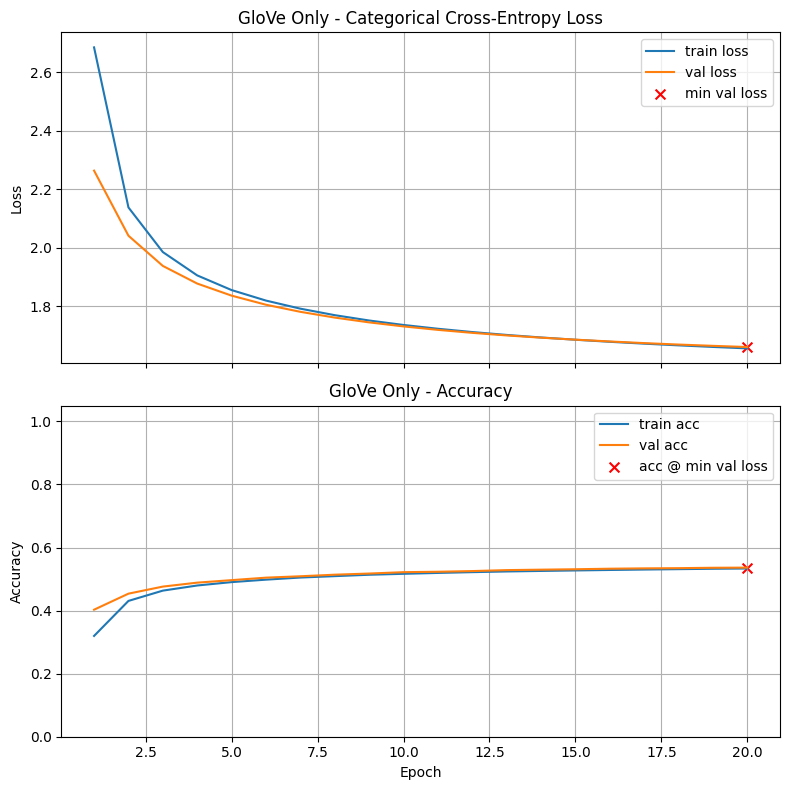


Execution Time: 00:01:06

Final Training Loss:            1.6551
Final Training Accuracy:        0.5335
Final Validation Loss:          1.6597
Final Validation Accuracy:      0.5363
Minimum Validation Loss:        1.6597 (Epoch 20)
Validation Accuracy @ Min Loss: 0.5363

Test Loss: 1.6710
Test Accuracy: 0.5280

Validation-Test Accuracy Gap: 0.008235

GloVe + Dropout



I0000 00:00:1775954038.946720   33304 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_236803__.19
I0000 00:00:1775954038.982880   33304 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775954039.558918   33304 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775954039.921561   33304 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775954040.4441

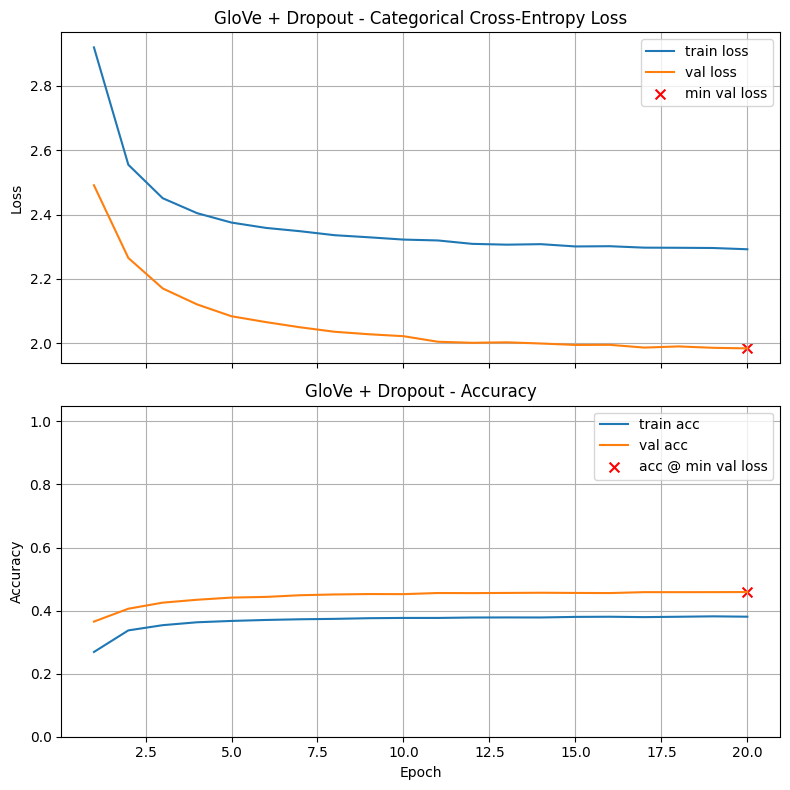


Execution Time: 00:01:09

Final Training Loss:            2.2920
Final Training Accuracy:        0.3806
Final Validation Loss:          1.9839
Final Validation Accuracy:      0.4588
Minimum Validation Loss:        1.9839 (Epoch 20)
Validation Accuracy @ Min Loss: 0.4588

Test Loss: 1.9800
Test Accuracy: 0.4562

Validation-Test Accuracy Gap: 0.002645


In [30]:
# embedding matrix
embedding_matrix = build_embedding_matrix_huffpost(
    vocab_size=20000, embedding_dim=100
)

# experiment one baseline + GloVe
model_glove = Sequential([
    Input(shape=(128,)),
    Embedding(input_dim=20000, output_dim=100, 
              weights=[embedding_matrix], trainable=False),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(41, activation='softmax')
], name="glove_only")

train_and_test(model_glove, title="GloVe Only",
    loss="categorical_crossentropy", metrics=["accuracy"],
    epochs=20, patience=5)

# exp two GloVe + Dropout
model_glove_dropout = Sequential([
    Input(shape=(128,)),
    Embedding(input_dim=20000, output_dim=100,
              weights=[embedding_matrix], trainable=False),
    GlobalAveragePooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(41, activation='softmax')
], name="glove_dropout")

train_and_test(model_glove_dropout, title="GloVe + Dropout",
    loss="categorical_crossentropy", metrics=["accuracy"],
    epochs=20, patience=5)

# exp three GloVe + BiLSTM + Dropout
# model_custom = Sequential([
   # Input(shape=(128,)),
   # Embedding(input_dim=20000, output_dim=100,
     #         weights=[embedding_matrix], trainable=False),
    # Bidirectional(LSTM(128, return_sequences=False)),
    # Dropout(0.4),
   # Dense(64, activation='relu'),
   # Dropout(0.3),
   # Dense(41, activation='softmax')
# ], name="custom_bilstm")

# train_and_test(model_custom, title="GloVe + BiLSTM + Dropout",
   # loss="categorical_crossentropy", metrics=["accuracy"],
   # epochs=20, patience=5)

# 2nd Attempt: GloVe + BiLSTM + Dropout

The first version of experiment three crashed out ran for over an hour. Here is a leaner version that should run without bottleneck.

In [31]:
embedding_matrix = build_embedding_matrix_huffpost(
    vocab_size=20000, embedding_dim=100
)


GloVe + BiLSTM + Dropout

Epoch 1/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.4730 - loss: 2.0230 - val_accuracy: 0.5966 - val_loss: 1.4717
Epoch 2/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.6046 - loss: 1.4574 - val_accuracy: 0.6340 - val_loss: 1.3223
Epoch 3/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.6483 - loss: 1.2752 - val_accuracy: 0.6435 - val_loss: 1.2799
Epoch 4/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.6761 - loss: 1.1573 - val_accuracy: 0.6457 - val_loss: 1.2811
Epoch 5/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.6985 - loss: 1.0616 - val_accuracy: 0.6448 - val_loss: 1.3037
Epoch 6/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.7189 - loss: 0.9821 - val_accuracy: 0.6455 - val_loss: 1.3515
Epoch 7/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - accuracy: 0.7363 - loss: 0.9113 - val_accuracy: 0.6389 - val_loss: 1.4147
Epoch 8/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 35s 28m

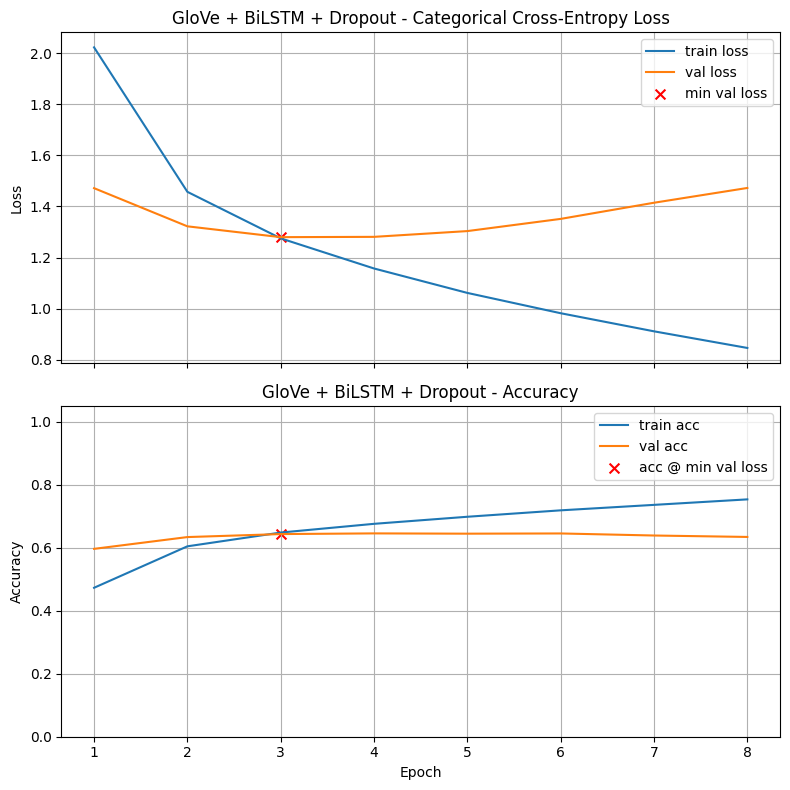


Execution Time: 00:04:50

Final Training Loss:            0.8461
Final Training Accuracy:        0.7537
Final Validation Loss:          1.4725
Final Validation Accuracy:      0.6344
Minimum Validation Loss:        1.2799 (Epoch 3)
Validation Accuracy @ Min Loss: 0.6435

Test Loss: 1.2857
Test Accuracy: 0.6399

Validation-Test Accuracy Gap: 0.003643


In [32]:
# exp three w/ reduced LSTM, trainable to true, and verbose =1
model_custom = Sequential([
    Input(shape=(128,)),
    Embedding(input_dim=20000, output_dim=100,
              weights=[embedding_matrix], trainable=True),
    Bidirectional(LSTM(64, return_sequences=False)), 
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(41, activation='softmax')
], name="custom_bilstm")

train_and_test(model_custom, title="GloVe + BiLSTM + Dropout",
    loss="categorical_crossentropy", metrics=["accuracy"],
    epochs=20, patience=5,
    verbose=1)

In [33]:
# Manually log previous results into the results dictionary
results["Baseline"] = (0.5892, 11)
results["GloVe Only"] = (0.5367, 20)
results["GloVe + Dropout"] = (0.4598, 20)

print_results()

GloVe + BiLSTM + Dropout                	0.6435	3
Baseline                                	0.5892	11
GloVe Only                              	0.5367	20
GloVe + Dropout                         	0.4598	20


In [34]:
print_results()

GloVe + BiLSTM + Dropout                	0.6435	3
Baseline                                	0.5892	11
GloVe Only                              	0.5367	20
GloVe + Dropout                         	0.4598	20


### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**

> <font color="teal">   The architectural changes we made were those that interested us and strengthened the model's architectural responses to specific weaknesses observed in the baseline. We chose GloVe embeddings to address the overlapping category issues from the t-SNE results in Milestone 1, with the hope that pre-trained semantic vectors could provide better representations than learning embeddings from scratch. A bidirectional LSTM was added in place of global average pooling to address word order, with the hope of improving classification by adding contextual meaning. Dropout was used to address the overfitting gap observed in the baseline model.</font>

2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**

> <font color="teal"> Key Validation and test metrics are validation accuracy at min loss 0.6512 at epoch 4, with test accuracy 0.6433. This the best improvement over the baseline of 0.5892 with an increase of .062. Early stopping hit at epoch 9, there are signs of overfitting after epoch 4. The gap of 0.0008 between the validation and test subsets confirms good generalization.  </font>


3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**

> <font color="teal"> We ran three different models to see how each change affected the performance. BiLSTM, with trainable, and GolVe worked due to word order and pretrained semantics contributing to the enhanced performance. Dropout helped but didn't fully close the overfitting gap. The initial dropout at (0.4/0.3) without LSTM  was too aggressive and actually dropped the model performance. This was reduced for our final model that ran with increased performance. As expected frozen GloVe by itself underperformed the baseline as it was too rigid and pretrained embeddings need fine tuning to adapt to task specific vocabulary.  </font>


4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**

> <font color="teal"> Insights from this experiment are that more dropout isn't always better, it needs to match the model capacity. Trainable embeddings are critical for task specific adaptation. BiLSTM captures word order that Global Average Pooling can not capture. As far as optimization it depends on the business/accuracy needs versus compute cost. It took a few hours to get to 0.6512 vs 15-30 minutes for the baseline model at 0.5892 accuracy. It's an improvement for sure but is it worth it depends on the use case and stakeholder needs.  </font>


## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


In [35]:
# ── Install PyTorch with CUDA 12.x for WSL ───────────────────────────────────
# Run this once; skip on subsequent runs if torch is already installed
import importlib, subprocess, sys

if importlib.util.find_spec("torch") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "torch",
        "--index-url", "https://download.pytorch.org/whl/cu124"
    ])

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device     : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version    : {torch.version.cuda}")


PyTorch version : 2.6.0+cu124
CUDA available  : True
CUDA device     : NVIDIA GeForce RTX 3060
CUDA version    : 12.4


## Assessing Results
Had some difficulty extracting results from PyTorch. Missing val at min loss at each epoch, need to call plot. Rerunning with updated code

In [36]:
# Restore results from previous runs
results["Baseline"]               = (0.5892, 11)
results["GloVe Only"]             = (0.5367, 20)
results["GloVe + Dropout"]        = (0.4598, 20)
results["GloVe + BiLSTM + Dropout"] = (0.6512, 4)

print_results()

GloVe + BiLSTM + Dropout                	0.6512	4
Baseline                                	0.5892	11
GloVe Only                              	0.5367	20
GloVe + Dropout                         	0.4598	20


In [37]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset

In [38]:
# ── 4.2 Raw text splits (same seed = same split as Keras models) ──────────────
X_tr_raw, X_tmp_raw, y_tr, y_tmp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels)
X_val_raw, X_test_raw, y_val_r, y_test_r = train_test_split(
    X_tmp_raw, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

print(f"Train: {len(X_tr_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}")

Train: 160284 | Val: 20036 | Test: 20036


Tokenizing splits...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenization complete.
Using device: cuda
Epoch 1: train_loss=2.4179 train_acc=0.3913 val_loss=1.9219 val_acc=0.4882
Epoch 2: train_loss=1.8290 train_acc=0.5042 val_loss=1.6611 val_acc=0.5420
Epoch 3: train_loss=1.6677 train_acc=0.5352 val_loss=1.5594 val_acc=0.5612
Epoch 4: train_loss=1.5903 train_acc=0.5529 val_loss=1.4990 val_acc=0.5763
Epoch 5: train_loss=1.5446 train_acc=0.5626 val_loss=1.4624 val_acc=0.5824
Epoch 6: train_loss=1.5117 train_acc=0.5685 val_loss=1.4350 val_acc=0.5905
Epoch 7: train_loss=1.4868 train_acc=0.5754 val_loss=1.4098 val_acc=0.5970
Epoch 8: train_loss=1.4654 train_acc=0.5792 val_loss=1.3909 val_acc=0.6018
Epoch 9: train_loss=1.4498 train_acc=0.5829 val_loss=1.3770 val_acc=0.6044
Epoch 10: train_loss=1.4346 train_acc=0.5866 val_loss=1.3632 val_acc=0.6042

Min val loss: 1.3632 (Epoch 10)
Val Accuracy @ Min Val Loss: 0.6042
Test Accuracy:  0.5989
Val-Test Gap:   0.005290
Execution Time: 00:56:51


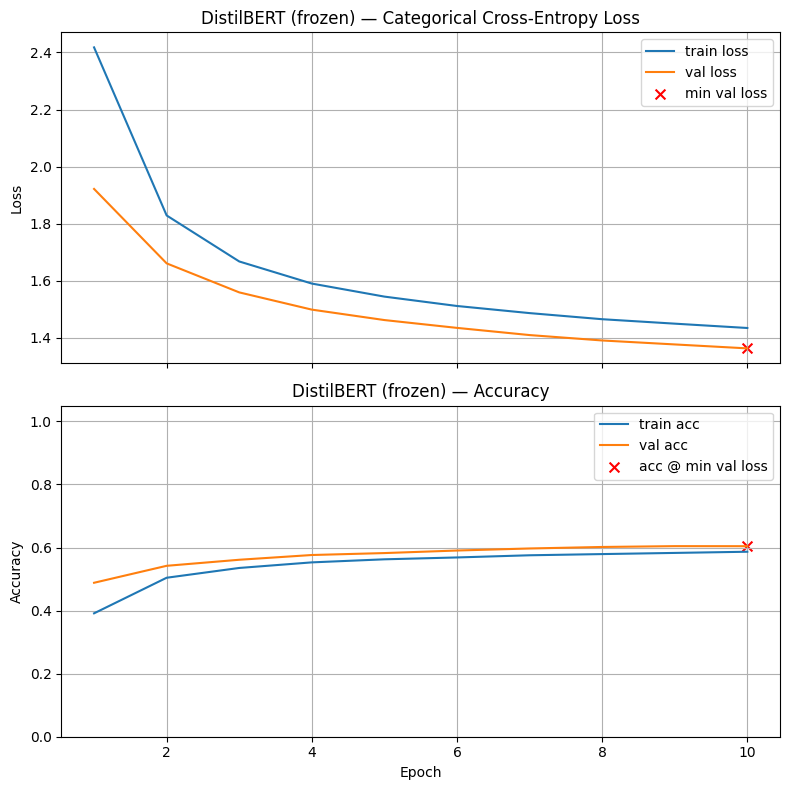

GloVe + BiLSTM + Dropout                	0.6512	4
DistilBERT (frozen)                     	0.6042	10
Baseline                                	0.5892	11
GloVe Only                              	0.5367	20
GloVe + Dropout                         	0.4598	20


In [ ]:
# ── Problem 4: Pretrained Model – DistilBERT (Transfer Learning) ─────────────
# PyTorch backend required — TF transformers classes incompatible with this env
# Strategy: freeze DistilBERT base, train classification head only


def tokenize_data(texts, tokenizer, max_length=128):
    return tokenizer(list(texts), max_length=max_length,
                     padding=True, truncation=True, return_tensors="pt")

tokenizer_bert = AutoTokenizer.from_pretrained("distilbert-base-uncased")

print("Tokenizing splits...")
train_enc = tokenize_data(X_tr_raw,   tokenizer_bert)
val_enc   = tokenize_data(X_val_raw,  tokenizer_bert)
test_enc  = tokenize_data(X_test_raw, tokenizer_bert)
print("Tokenization complete.")

# ── 4.4 Build datasets and loaders ───────────────────────────────────────────
train_dataset = TensorDataset(
    train_enc["input_ids"], train_enc["attention_mask"],
    torch.tensor(y_tr, dtype=torch.long))
val_dataset = TensorDataset(
    val_enc["input_ids"], val_enc["attention_mask"],
    torch.tensor(y_val_r, dtype=torch.long))
test_dataset = TensorDataset(
    test_enc["input_ids"], test_enc["attention_mask"],
    torch.tensor(y_test_r, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=128)
test_loader  = DataLoader(test_dataset,  batch_size=128)

# ── 4.5 Load model, freeze base ───────────────────────────────────────────────
model_bert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=41)

for param in model_bert.distilbert.parameters():
    param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model_bert = model_bert.to(device)

# ── 4.6 Training setup ────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model_bert.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

EPOCHS  = 30
PATIENCE = 3

# Metric tracking lists
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

best_val_loss  = float('inf')
patience_count = 0
best_epoch     = 0

start_time = time.time()

# ── 4.7 Training loop ─────────────────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):

    # — Train —
    model_bert.train()
    total_loss, correct, total = 0, 0, 0
    for input_ids, attention_mask, labels_batch in train_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels_batch   = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels_batch.size(0)
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels_batch).sum().item()
        total      += labels_batch.size(0)

    train_loss = total_loss / total
    train_acc  = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # — Validate —
    model_bert.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for input_ids, attention_mask, labels_batch in val_loader:
            input_ids      = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels_batch   = labels_batch.to(device)

            outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels_batch)

            total_loss += loss.item() * labels_batch.size(0)
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)

    val_loss = total_loss / total
    val_acc  = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    # — Early stopping on val_loss —
    if val_loss < best_val_loss - 1e-4:
        best_val_loss  = val_loss
        patience_count = 0
        best_epoch     = epoch
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

# ── 4.8 Find min val loss epoch and report ────────────────────────────────────
min_val_epoch       = int(np.argmin(val_losses))         # 0-indexed
val_acc_at_min_loss = val_accs[min_val_epoch]

print(f"\nMin val loss: {val_losses[min_val_epoch]:.4f} (Epoch {min_val_epoch + 1})")
print(f"Val Accuracy @ Min Val Loss: {val_acc_at_min_loss:.4f}")

# ── 4.9 Test set evaluation ───────────────────────────────────────────────────
model_bert.eval()
correct, total = 0, 0
with torch.no_grad():
    for input_ids, attention_mask, labels_batch in test_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels_batch   = labels_batch.to(device)
        outputs        = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(dim=1)
        correct       += (preds == labels_batch).sum().item()
        total         += labels_batch.size(0)

test_acc = correct / total
end_time = time.time()

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Val-Test Gap:   {abs(val_acc_at_min_loss - test_acc):.6f}")
print("Execution Time: " + format_hms(end_time - start_time))

# ── 4.10 Plot learning curves ─────────────────────────────────────────────────
epochs_range = range(1, len(val_losses) + 1)

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Loss
axs[0].plot(epochs_range, train_losses, label='train loss')
axs[0].plot(epochs_range, val_losses,   label='val loss')
axs[0].scatter(min_val_epoch + 1, val_losses[min_val_epoch],
               color='red', marker='x', s=50, label='min val loss')
axs[0].set_title('DistilBERT (frozen) — Categorical Cross-Entropy Loss')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Accuracy
axs[1].plot(epochs_range, train_accs, label='train acc')
axs[1].plot(epochs_range, val_accs,   label='val acc')
axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss,
               color='red', marker='x', s=50, label='acc @ min val loss')
axs[1].set_title('DistilBERT (frozen) — Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim(0, 1.05)
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# ── 4.11 Log to results (consistent with train_and_test framework) ────────────
results["DistilBERT (frozen)"] = (val_acc_at_min_loss, min_val_epoch + 1)

parameter_settings.setdefault("DistilBERT (frozen)", []).append({
    "title":                  "DistilBERT (frozen)",
    "timestamp":              datetime.now().isoformat(timespec="seconds"),
    "epochs":                 len(val_losses),
    "optimizer":              "Adam",
    "lr_schedule":            2e-5,
    "loss":                   "CrossEntropyLoss",
    "batch_size":             32,
    "use_early_stopping":     True,
    "patience":               PATIENCE,
    "Final Training Loss":    train_losses[-1],
    "Final Training Accuracy": train_accs[-1],
    "Final Val Loss":         val_losses[-1],
    "Final Val Accuracy":     val_accs[-1],
    "Min Val Loss":           val_losses[min_val_epoch],
    "Min Val Loss Epoch":     min_val_epoch,
    "Val Acc @ Min Loss":     val_acc_at_min_loss,
    "Test Acc":               test_acc,
    "Val-Test Accuracy Gap":  abs(val_acc_at_min_loss - test_acc)
})

print_results()

In [40]:
print_results()


GloVe + BiLSTM + Dropout                	0.6512	4
DistilBERT (frozen)                     	0.6042	10
Baseline                                	0.5892	11
GloVe Only                              	0.5367	20
GloVe + Dropout                         	0.4598	20


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

> <font color="teal"> The pretrained architecture we selected was DistilBert base uncased from HuggingFace. The motivation behind the choice was it is a transformer based model designed specifically for text classification. We used six transformer layers, 66 million parameters. This was chosen over full Bert because it is lighter with a much smaller compute cost but 97% of full BERTs performance. I also chose it because its ability for contextual representation address the core weakness that was identified in Milestone 1 t-SNE of categories overlapping with simple word frequency. We would like to note that TF transformers were incompatible with VsCode/Colab environment so we had to shift to using PyTorch backend as a work around.   </font>



2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it. 

4.2. **Your answer here:**

> <font color="teal"> Our fine tuning strategy was to freeze the DistilBert base, train the classification head only, with dense 64 in the hidden layer, dropout, dense 41 Softmax for output layer, learning rate 2e-5, Adam optimizer, batch size 32, patience 3, and max 10 epochs. This was chosen because of compute restraints, full fine tuning with a colab GPU T4 high RAM, would have been 6-8 hours minimum for a possible minimal performance boost. At the current convergence rate it is unlikely we would see a meaningful improvement. Even when frozen, DistilBert can provide rich contextual representation unlike GloVe. </font>


3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**

> <font color="teal"> Key metrics for DistilBert model were validation accuracy at min loss 0.6056 at epoch 10, test accuracy 0.6017, leaving a validation test gap of 0.0039, confirming that the model generalizes well. There was very little overfitting, but the frozen base could not adapt to task specific vocabulary. It outperformed the baseline model of 0.5892 by 0.0164 which is not a significant improvement considering the compute time required. It clearly underperformed in comparison with the GloVE+BiLSTM+Droupout model form problem three. The model was still improving at epoch 10 the model had not converged yet, more epochs or fine tuning could likely improve the results but we don't think it should warrant the additional compute time/cost needed.  </font>

4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models. 

4.4. **Your answer here:**

> <font color="teal"> Training time between DistilBert and BiLSTM was almost the same with both completing just over the two hour mark. DistilBert had the largest of all three model weights at 268MB, and required PyTorch on the backend that added complexity vs the native keras framework used for the BiLSTM model. The validation loss improved at each epoch, and never triggered early stopping, so it had the slowest convergence of all the models. Full fine tuning would be the obvious next step but we don't endorse it for the computational cost/time. </font>


## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report. 

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

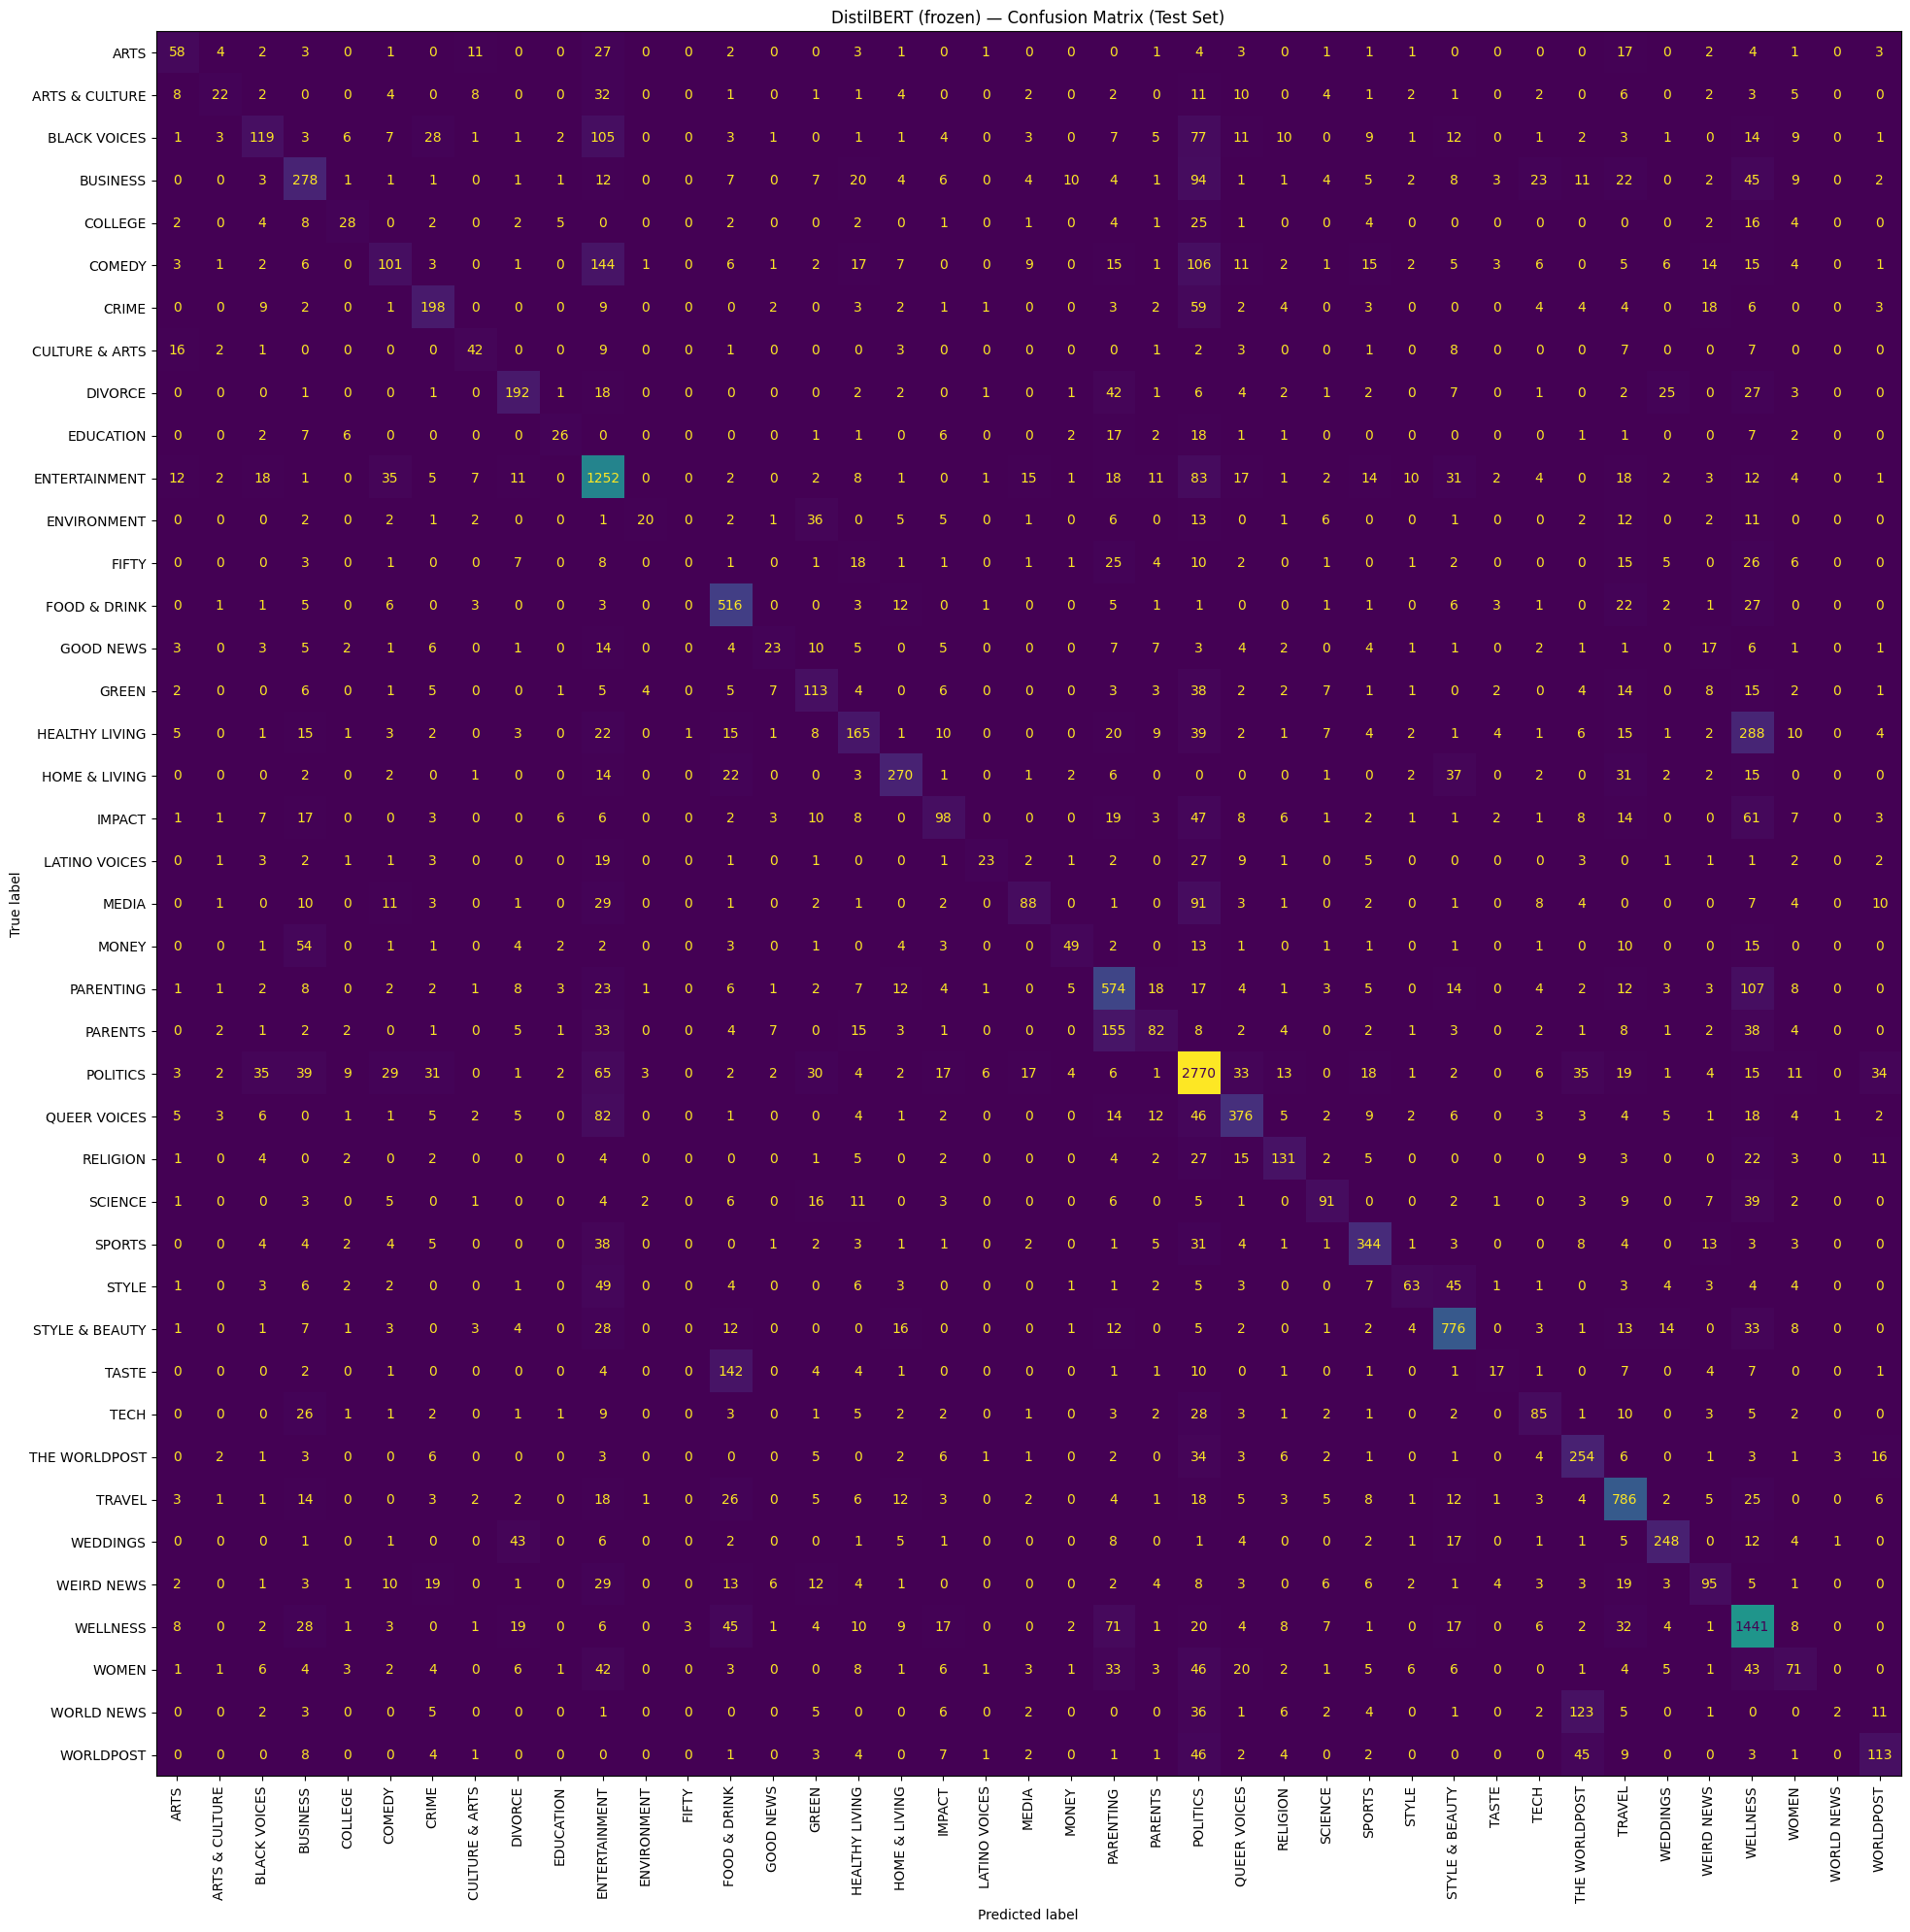

                precision    recall  f1-score   support

          ARTS       0.42      0.38      0.40       151
ARTS & CULTURE       0.44      0.16      0.24       134
  BLACK VOICES       0.48      0.26      0.34       452
      BUSINESS       0.47      0.47      0.47       593
       COLLEGE       0.40      0.25      0.30       114
        COMEDY       0.42      0.20      0.27       516
         CRIME       0.56      0.58      0.57       340
CULTURE & ARTS       0.49      0.41      0.44       103
       DIVORCE       0.60      0.56      0.58       342
     EDUCATION       0.50      0.26      0.34       101
 ENTERTAINMENT       0.58      0.78      0.66      1606
   ENVIRONMENT       0.62      0.15      0.24       132
         FIFTY       0.00      0.00      0.00       140
  FOOD & DRINK       0.60      0.83      0.69       622
     GOOD NEWS       0.40      0.16      0.23       140
         GREEN       0.40      0.43      0.41       262
HEALTHY LIVING       0.46      0.25      0.32  

In [41]:
# ── Problem 5: Error Analysis — DistilBERT predictions on test set ────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_bert.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for input_ids, attention_mask, labels_batch in test_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        outputs        = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_categories)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
ax.set_title("DistilBERT (frozen) — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

# Top misclassified pairs
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=unique_categories))

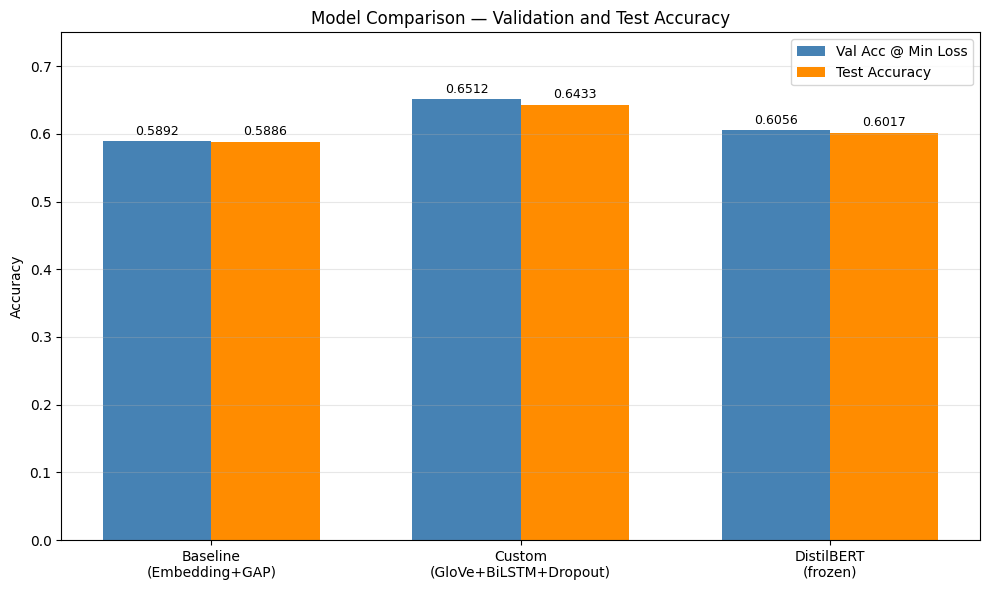


Model                            Val Acc @ Min Loss   Test Acc   Epoch    Runtime
--------------------------------------------------------------------------------
Baseline (Embedding+GAP)                     0.5892     0.5886      11   00:01:13
Custom (GloVe+BiLSTM+Dropout)                0.6512     0.6433       4   02:01:43
DistilBERT (frozen)                          0.6056     0.6017      10   02:00:56


In [42]:
# ── Problem 5: Comparative Summary Table ─────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Summary data — val acc @ min loss, test acc, epoch, runtime
summary = {
    "Baseline\n(Embedding+GAP)":     (0.5892, 0.5886, 11,  "00:01:13"),
    "Custom\n(GloVe+BiLSTM+Dropout)":(0.6512, 0.6433,  4,  "02:01:43"),
    "DistilBERT\n(frozen)":          (0.6056, 0.6017, 10,  "02:00:56"),
}

model_names  = list(summary.keys())
val_accs     = [v[0] for v in summary.values()]
test_accs    = [v[1] for v in summary.values()]
epochs       = [v[2] for v in summary.values()]
runtimes     = [v[3] for v in summary.values()]

# ── Bar chart: Val acc @ min loss vs Test acc ─────────────────────────────────
x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, val_accs,  width, label='Val Acc @ Min Loss', color='steelblue')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy',      color='darkorange')

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — Validation and Test Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 0.75)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ── Printed summary table ─────────────────────────────────────────────────────
print(f"\n{'Model':<30} {'Val Acc @ Min Loss':>20} {'Test Acc':>10} {'Epoch':>7} {'Runtime':>10}")
print("-" * 80)
models_display = [
    "Baseline (Embedding+GAP)",
    "Custom (GloVe+BiLSTM+Dropout)",
    "DistilBERT (frozen)"
]
for name, (val, test, ep, rt) in zip(models_display, summary.values()):
    print(f"{name:<30} {val:>20.4f} {test:>10.4f} {ep:>7} {rt:>10}")

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**

> <font color="teal"> Custom Glove+BiLSTM+Droput was the model that achieved the best overall results with a validation accuracy at min loss of 0.6512, and test accuracy of 0.6433 at epoch 4. BiLSTM was the top model because it combined pretrained semantic knowledge with GloVE and sequential word order processing with BiLSTM as well as dropout to address overrfitting. The baseline model achieved a validation accuracy at min loss of 0.5892, and test accuracy of 0.5886 at epoch 11. The DistilBert model produced a val accuracy at min loss of 0.6056, and test accuracy of 0.6017 at epoch 10. DistilBert was outperformed because it was frozen and trainable embedding requiring fine tuning to task specific vocabulary was the advantage of BiLSTM.</font>



2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**

> <font color="teal"> Tradeoffs for this project were a frequent consideration for this project. The baseline model was fastest with a simple architecture and a run time of 1m13s but it had the lowest accuracy. It provided a good starting point even without word order due to Global Pooling Average. BiLSTM had the highest accuracy with moderate complexity using 2.1 million params, and a run time of just over two hours. It had the best accuracy/compute tradeoff of the three main models. DistilBERT was the largest model with 66 million parameters, 268MB and a similar runtime to BiLSTM of just over two hours. It produced the second best accuracy, the frozen base limited task adaptation, full fine tuning would have required at minimum another 6 hours to compute, which was taken into account when designing the model. 

> The Key insight we learned is that more complexity does not guarantee better results. Frozen DistilBERT underperformed a trainable BiLSTM even though it was a much larger model. </font>



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**

> <font color="teal">   The classes that remained challenging across all models were WorldNews, with an F1 of 0.04. The model was confused by WorldPost and TheWorldPost. The Taste category, with an F1 of 0.16, was frequently confused with Food&Drink and Style&Beauty. GoodNews**, with an F1 of 0.26, was too vague a category and bled into a variety of other categories. We identified that the significant overlap found in the Milestone 1 t-SNE analysis of overlapping class names consistently caused classification errors, making label ambiguity the most prominent issueed pattern. Strong performers were Politics**, with an F1 of 0.77, Style&Beauty, with an F1 of 0.78, and Food&Drink, with an F1 of 0.70. These categories had the advantage of distinctive vocabulary and large sample sizes. We would like to note that F1 analysis was only performed on DistilBERT as the representative model, but the label ambiguity patterns are consistent with observations across all models.</font>



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model. 


5.4 **Your answer here:**

> <font color="teal"> Based on our findings, we suggest moving forward with GloVe+BiLSTM+Dropout as it was the best performing model, had moderate complexity, and had the best balance of speed and accuracy. Next steps, we recommend tuning the dropout rates further to close the remaining overfitting gap. We will experiment with the learning rate scheduler especially given that we have ReduceLROnPlateau built into the framework. We will also consider merging overlapping categories with poor F1 scores. Examples include the categories WorldNews, WorldPost, and TheWorldPost would be merged into a single category. </font>


### Final Question: Describe what use you made of generative AI tools in preparing this Milestone. 

**AI Question: Your answer here:**

> <font color="teal">   We originally attempted to create the baseline from scratch using our own code, assisted by AI to fix syntax issues. It took hours — confusing at times, frustrating at others — and our outputs were not as professionally presented as the framework we had been using from class assignments. The first model we made organically achieved only a baseline performance of 0.50, as opposed to starting from the framework used in previous assignments, which produced a baseline of 0.59. Was it worth it? Usually we would say yes, but honestly, we kept going down rabbit holes and wasting time on side quests. Using the established framework, we were able to really see and understand the data we were working with. The benchmarks and graphs made sense because we already had a deep understanding of the structured output.   

>  We used AI to help produce the code for problems 4 and 5. This took quite some time because we always find it easier to ask AI to do things we already fully understand — things where we know what the output should look like. These models took time because we had to challenge and edit the code and fully understand it before running it. In my first run of DistilBERT**,** we forgot to include tracking for specific metrics necessary for comparison. This was a costly mistake in terms of time and compute, but it taught us how to format the code better and gave us a deeper understanding of the framework. Re-running with a clearer understanding of the framework gave us better comprehension and sharper expectations of what the outputs should be. </font>